# Measuring instrument

The DIN standard 1319 designates a measuring device - also called "measuring transducer", "measuring equipment" or "measuring device" - as an instrument that converts an input variable into an output variable according to a given transformation rule. Measuring devices are particularly important in control and regulation technology. In our case, the measuring instruments transform the physical quantities of the respective measuring points, which can be measured within a defined range, into a DIN IEC 60381-1 compliant signal in the 4.0 mA to 20.0 mA range. For example, the measuring range of the resistance thermometer PT 100 of the commonly used class B is -50 °C to 500 °C.

<img src = "./model.svg" width=150px>

## Model equations

The equations for this transformation are as follows.

The measuring range of the instrument determines the range of values of the physical quantity $m$ that is measured.

$$x_m = \max(\min(m, m_{max}), m_{min})$$

The meter output $s$ follows a linear equation.

$$ y = a \cdot (x_m - m_{min}) + b $$

With

$$ b = s_{min}$$

and

$$ a = \frac{s_{max} - s_{min}}{m_{max} - m_{min}}$$

and substition the following results:

$$ y = \frac{s_{max} - s_{min}}{m_{max} - m_{min}} \cdot (x_m - m_{min}) + s_{min}$$

## Parameters

The equations are calculated with the following parameters.

| Parameter | Symbol | Value | Unit | 
| :------- | :----: | :---: | :---- |
| Measurement range | $m_{min}$, $m_{max}$ | 223.15 - 770.15 | K |
| Signal range | $s_{min}$, $s_{max}$ | 4.0 - 20.0 | mA |

## Implementation of the model


In [1]:
from simunetcore import Model
import numpy as np

# Model implementation for the Measure Instrument
class Instrument(Model):
    def __init__(self, name:str=""):
        Model.__init__(self, name)
        # Model parameters
        self.params = {
            # Parameters signal range
            "s_range": {"value": [4.0, 20.0], "description": "Signal range (DIN IEC 60381-1)", "unit": "mA"},
            "m_range": {"value": [223.15, 770.15], "description": "Measurement range", "unit": "K"}
        }
        # Model variables
        self.vars = {
            "m" : {"description": "Measurement input", "unit": "K"}, 
            "s" : {"description": "Signal output", "unit": "mA"}
        }
        # Model inputs
        self.u = {
            "u_1" : {"type": "measure", "description": "Instrument input", "vars": ["m"]}
        }
        # Model outputs
        self.y = {
            "y_1" : {"type": "signal", "description": "Instrument output", "vars": ["s"]}
        }
             
    def compute(self, *args, **kwargs):
        # Get parameter q_range
        m_range = self.get_param("m_range") # Measurement range
        s_range = self.get_param("s_range") # Signal range (DIN IEC 60381-1) [mA]
        
        # Get measurement
        x = self.get_var("m")
        x = np.maximum(np.minimum(x, m_range[-1]), m_range[0])

        # linear characteristics follows y = a*x + b
        a = (s_range[-1]-s_range[0])/(m_range[-1]-m_range[0])
        b = s_range[0]
        y = a * (x - m_range[0]) + b

        # Store results
        self.set_var("s", y)


## Computation of the model

In [2]:
# Create model
M_5 = Instrument("M_5")

# Setup integration time
t_start = 0.0
t_end = 300.0
numpoints = 1001
M_5.set_t(np.linspace(t_start, t_end, numpoints))

# Setup imput vector
m = np.linspace(100.0, 900.0, numpoints)
u_1 = [m]
M_5.set_u("u_1", u_1)

# Solve model
M_5.compute()

## Results

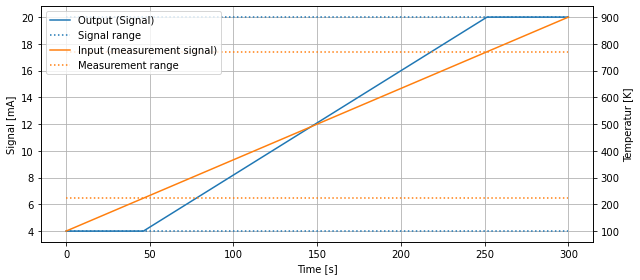

In [3]:
import matplotlib
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(9, 4))

# Show values
ln_1=plt.plot(M_5.get_t(), M_5.get_var("s"), "C0", label="Output (Signal)")
ln_1_1 = plt.plot(
    [M_5.get_t()[0], M_5.get_t()[-1]], 
    [M_5.get_param("s_range")[0], M_5.get_param("s_range")[0]], 
    "C0:", label="Signal range")
plt.plot(
    [M_5.get_t()[0], M_5.get_t()[-1]], 
    [M_5.get_param("s_range")[-1], M_5.get_param("s_range")[-1]], "C0:")

# Axis labels
plt.ylabel("Signal [mA]")
plt.xlabel("Time [s]")

# Second grid
plt.grid()

# Twin axis
plt.twinx()

ln_2 = plt.plot(M_5.get_t(), M_5.get_var("m"), "C1", label="Input (measurement signal)")
ln_2_2 = plt.plot(
    [M_5.get_t()[0], M_5.get_t()[-1]], 
    [M_5.get_param("m_range")[0], M_5.get_param("m_range")[0]], 
    "C1:", label="Measurement range")
plt.plot(
    [M_5.get_t()[0], M_5.get_t()[-1]], 
    [M_5.get_param("m_range")[-1], M_5.get_param("m_range")[-1]], "C1:")

# Axis labels
plt.ylabel("Temperatur [K]")

# Show legend
lines = ln_1 + ln_1_1 + ln_2 + ln_2_2
labels = [line.get_label() for line in lines]
plt.legend(lines, labels, loc=2)  

# Layout and show
plt.tight_layout()
plt.show()